<a href="https://colab.research.google.com/github/tenacioussami/NLP/blob/main/Skill_Morph_Basic_NLP_Sentiment_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🎬 Introduction to Natural Language Processing (NLP)
## Sentiment Analysis with IMDb Movie Reviews

**Instructor:** Md. Samiul Islam  
**Institution:** Skill Morph Research Lab
**Duration:** 1 hour 30 minutes

---

### 📚 Learning Objectives
By the end of this class, you will be able to:
1. Understand what NLP is and why it matters
2. Load and explore text datasets
3. Preprocess text data (cleaning, tokenization)
4. Convert text into numerical features (Bag-of-Words)
5. Build a simple sentiment analysis model
6. Evaluate model performance

---

### 📊 Dataset
**IMDb Movie Reviews** - 50,000 reviews labeled as positive or negative  
We'll use a small subset (5000 reviews) for faster execution.

---

In [1]:
# Install required packages
!pip install nltk -q

# Import libraries
import pandas as pd
import numpy as np
import nltk
import re
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Download NLTK data (including punkt_tab for tokenization)
nltk.download('punkt', quiet=True)               #remove puntuation
nltk.download('punkt_tab', quiet=True)           #remove space
nltk.download('stopwords', quiet=True)           #remove am,is,the a etc

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [2]:

from google.colab import drive
drive.mount('/content/drive')
import warnings
warnings.filterwarnings('ignore')
# Load the dataset
df= pd.read_csv('/content/drive/MyDrive/datasets/IMDB Dataset.csv')

# Use only 5000 reviews for faster execution
df = df.sample(n=5000, random_state=20).reset_index(drop=True)

print("✅ Dataset loaded successfully!")
print(f"Total reviews: {len(df)}")

Mounted at /content/drive
✅ Dataset loaded successfully!
Total reviews: 5000


In [3]:
# Display first few reviews
print("📖 First 5 Reviews:")
df.head()

📖 First 5 Reviews:


,review,sentiment
0,"From the first to the last scene of the movie,...",positive
1,"Check out the film's website, more time was pu...",negative
2,"Well, Dude Where's My Car might be at least a ...",negative
3,"The first look on the cover of this picture, i...",negative
4,First off i'll give this movie a low scoring 4...,negative


In [4]:
# Check dataset shape
print(f"Dataset Shape: {df.shape}")

Dataset Shape: (5000, 2)


In [5]:
# Count positive vs negative reviews
sentiment_counts = df['sentiment'].value_counts()
print("📊 Sentiment Distribution:")
print(sentiment_counts)


📊 Sentiment Distribution:
sentiment
negative    2503
positive    2497
Name: count, dtype: int64


In [6]:
# Convert all text to lowercase
df['review_cleaned'] = df['review'].str.lower()

# Show example
print("Original Review:")
print(df['review'][0])

print("After Lowercase:")
print(df['review_cleaned'][0])

Original Review:
From the first to the last scene of the movie, director Visconti excels at his art, to the extent that the movie is ensured to remain as a cultural treasure for only God knows how long. It is perfection - as a movie, that is, but the story has some minor shortcomings.<br /><br />Thomas Mann's novel is also a perfect piece of art, so of course it is impossible to bring into another media. Visconti follows the story pretty much, and it is only when he allows himself to deviate slightly, that the transition falters. And no matter how wonderful the scenery is, the tension in the air between the characters, the hundreds of subtle signals and allegories, the almost unbearably heightened serving of Mahler's music - still, the minute anomalies in the plot disturb me.<br /><br />Maybe I'm just a victim of man's desire to flaw the flawless. Nevertheless, I will offer one example, which I regard as crucial.<br /><br />WARNING: SPOILERS<br /><br />In Mann's story, Aschenbach eats 

In [8]:
# Remove punctuation and special characters
df['review_cleaned'] = df['review_cleaned'].apply(lambda x: re.sub(r'[^a-zA-Z\s]', '', x))

# Show example
print("After Removing Punctuation:")
print(df['review_cleaned'][0])

After Removing Punctuation:
from the first to the last scene of the movie director visconti excels at his art to the extent that the movie is ensured to remain as a cultural treasure for only god knows how long it is perfection  as a movie that is but the story has some minor shortcomingsbr br thomas manns novel is also a perfect piece of art so of course it is impossible to bring into another media visconti follows the story pretty much and it is only when he allows himself to deviate slightly that the transition falters and no matter how wonderful the scenery is the tension in the air between the characters the hundreds of subtle signals and allegories the almost unbearably heightened serving of mahlers music  still the minute anomalies in the plot disturb mebr br maybe im just a victim of mans desire to flaw the flawless nevertheless i will offer one example which i regard as crucialbr br warning spoilersbr br in manns story aschenbach eats the strawberries which probably contain th

In [10]:
# Tokenize text (split into words)
from nltk.tokenize import word_tokenize

# Tokenize first 3 reviews as example
print("🔤 Tokenization Example:\n")
for i in range(3):
    tokens = word_tokenize(df['review_cleaned'][i])
    print(f"Review {i+1} Tokens (first 15 words):")
    print(tokens[:15])
    print(f"Total tokens: {len(tokens)}\n")

🔤 Tokenization Example:

Review 1 Tokens (first 15 words):
['from', 'the', 'first', 'to', 'the', 'last', 'scene', 'of', 'the', 'movie', 'director', 'visconti', 'excels', 'at', 'his']
Total tokens: 317

Review 2 Tokens (first 15 words):
['check', 'out', 'the', 'films', 'website', 'more', 'time', 'was', 'put', 'into', 'making', 'that', 'than', 'in', 'the']
Total tokens: 143

Review 3 Tokens (first 15 words):
['well', 'dude', 'wheres', 'my', 'car', 'might', 'be', 'at', 'least', 'a', 'novelty', 'as', 'one', 'of', 'few']
Total tokens: 167



In [13]:
# Create Bag-of-Words features
vectorizer = CountVectorizer(max_features=2000, stop_words='english')

# Convert text to numerical features
X = vectorizer.fit_transform(df['review_cleaned'])
y = df['sentiment'].map({'positive': 1, 'negative': 0})

print("✅ Text converted to numerical features!")
print(f"Feature matrix shape: {X.shape}")
print(f"\nExample feature names (first 10 words):")
print(vectorizer.get_feature_names_out()[:10])

✅ Text converted to numerical features!
Feature matrix shape: (5000, 2000)

Example feature names (first 10 words):
['ability' 'able' 'absolute' 'absolutely' 'absurd' 'academy' 'accent'
 'accents' 'accept' 'accident']


In [14]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("📊 Data Split:")
print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")

📊 Data Split:
Training samples: 4000
Testing samples: 1000


In [15]:
# Train Multinomial Naive Bayes classifier
model = MultinomialNB()
model.fit(X_train, y_train)

print("✅ Model trained successfully!")

✅ Model trained successfully!


In [16]:
# Make predictions on test set
y_pred = model.predict(X_test)

print("✅ Predictions completed!")
print(f"First 10 predictions: {y_pred[:10]}")
print(f"First 10 actual values: {y_test.values[:10]}")

✅ Predictions completed!
First 10 predictions: [0 0 0 1 0 1 0 1 0 0]
First 10 actual values: [0 0 1 1 0 1 0 1 0 0]


In [17]:
# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"🎯 Model Accuracy: {accuracy*100:.2f}%")

🎯 Model Accuracy: 80.90%


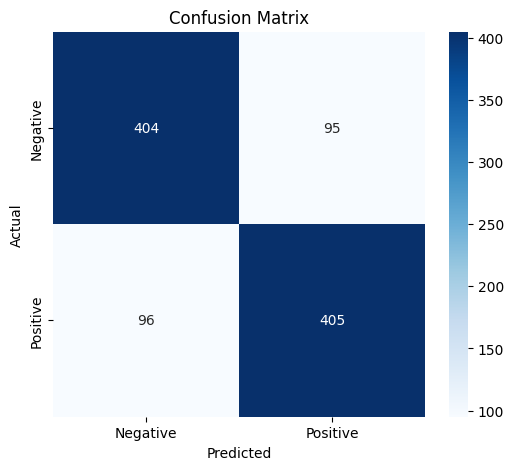

Confusion Matrix Interpretation:
True Negatives: 404
False Positives: 95
False Negatives: 96
True Positives: 405


In [18]:
# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Visualize confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

print("Confusion Matrix Interpretation:")
print(f"True Negatives: {cm[0,0]}")
print(f"False Positives: {cm[0,1]}")
print(f"False Negatives: {cm[1,0]}")
print(f"True Positives: {cm[1,1]}")

In [19]:
# Test model with a custom review
def predict_sentiment(review_text):
    # Preprocess
    cleaned = review_text.lower()
    cleaned = re.sub(r'[^a-zA-Z\s]', '', cleaned)

    # Vectorize
    features = vectorizer.transform([cleaned])

    # Predict
    prediction = model.predict(features)[0]
    sentiment = "Positive 😊" if prediction == 1 else "Negative 😞"

    return sentiment

# Test examples
test_reviews = [
    "This movie was absolutely amazing! I loved every minute of it.",
    "Worst movie ever. Complete waste of time and money.",
    "It was okay, nothing special but not terrible either."
]

print("🎬 Custom Review Predictions:\n")
for review in test_reviews:
    prediction = predict_sentiment(review)
    print(f"Review: {review}")
    print(f"Prediction: {prediction}\n")

🎬 Custom Review Predictions:

Review: This movie was absolutely amazing! I loved every minute of it.
Prediction: Positive 😊

Review: Worst movie ever. Complete waste of time and money.
Prediction: Negative 😞

Review: It was okay, nothing special but not terrible either.
Prediction: Negative 😞



# 🎉 Conclusion

## What We Learned Today:

1. **NLP Basics** - Understanding text as data
2. **Data Exploration** - Analyzing sentiment distribution
3. **Text Preprocessing** - Cleaning and preparing text
4. **Tokenization** - Breaking text into words
5. **Feature Extraction** - Converting text to numbers (Bag-of-Words)
6. **Machine Learning** - Training a Naive Bayes classifier
7. **Evaluation** - Measuring model performance (~85-87% accuracy)

---

## Key Takeaways:

✅ Text must be converted to numbers for machine learning  
✅ Simple preprocessing improves model performance  
✅ Naive Bayes works well for text classification  
✅ Even basic NLP models can achieve good accuracy  

---

## Next Steps:

- Learn about TF-IDF (better than Bag-of-Words)
- Try other classifiers (Logistic Regression, SVM)
- Explore word embeddings (Word2Vec, GloVe)
- Advanced: Transformers and BERT

---

# 📝 Assignment 1: Basic Sentiment Analysis

## Instructions:
Complete the following tasks and submit a PDF report with code and outputs.

---

### Task 1: Load and Explore
1. Load the full IMDb dataset (or 5000 reviews)
2. Display the **first 10 reviews** using `df.head(10)`
3. Count the number of **positive** and **negative** reviews



### Task 2: Analysis
Write **2-3 sentences** explaining:
- Which sentiment class has longer reviews on average?
- Why do you think this might be the case?

---

### Task 3: Simple Preprocessing
1. Create a new column called `word_count` that counts the number of words in each review
2. Find the review with the **highest word count**
3. Display that review



**Good luck! 🚀**